Class starts at 1210 please take time to do this! Thanks!
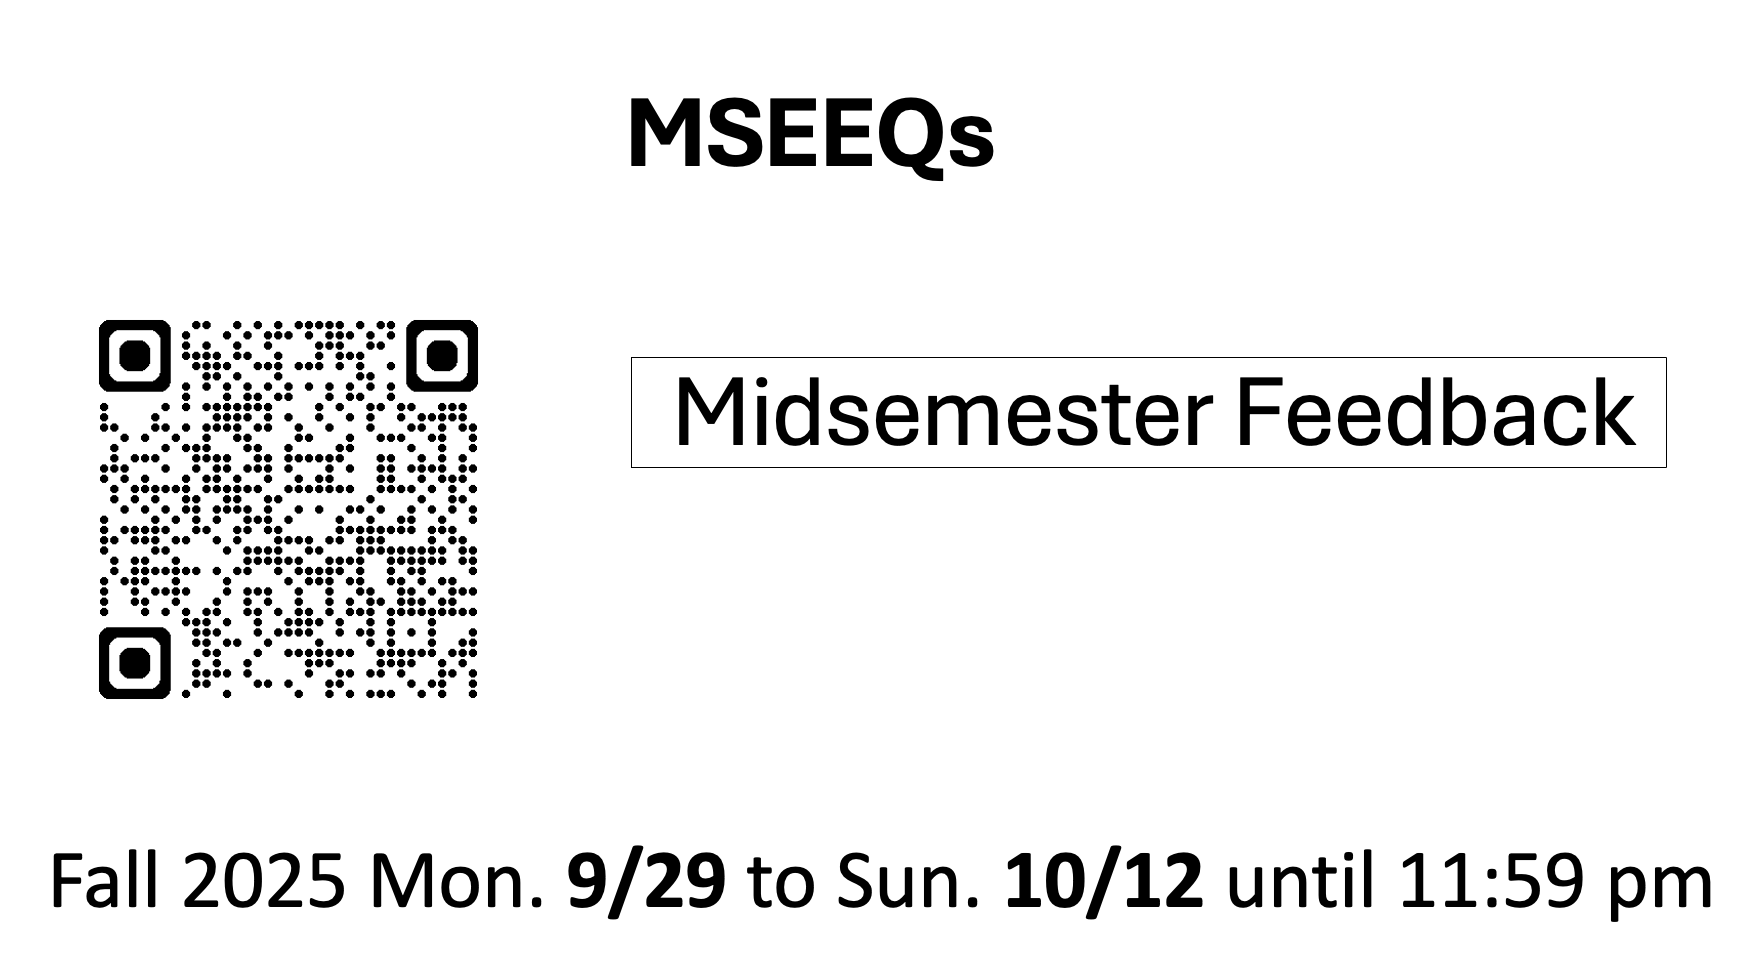

# **Outliers**

**Objective:** The objective of this lesson is to learn how to identify and handle outliers, which are data points that can distort the results of your analysis.
You will practice using visual tools like **box plots** and statistical methods like **Z-scores** to find and remove these extreme values, ensuring your dataset is clean and reliable.

### **What is an outlier?**
Outliers are data points that are significantly different from the majority of the data points in a dataset.



### **Why are outliers bad?**
These points can be problematic in data analysis because they can distort the results of statistical analysis, and can lead to incorrect conclusions or misleading insights.

### **Why do outliers happen?**
Outliers can occur for a variety of reasons:
 * **errors in data entry:** These occur when data is entered into a database or spreadsheet incorrectly, such as a misplaced decimal point or a typo. These types of outliers can be identified and corrected by double-checking the data and looking for patterns or discrepancies that don't match the rest of the data
 * **data collection or measurement:** These occur when data is measured incorrectly or inaccurately, such as due to faulty sensors or meters. These types of outliers can be identified and corrected by cross-checking the data with other measurements, or by calibrating the measurement equipment.
 * **Natural Variability:** These occur when a data point is genuinely different from the rest of the data due to natural variability, such as due to seasonal changes or changes in occupancy. These types of outliers may require further investigation to identify the underlying causes.
* **Unusual Events** These occur when a data point is significantly different from the rest of the data due to unusual events or circumstances, such as a power outage or extreme weather conditions. These types of outliers may require further investigation to identify the underlying causes, and may not be representative of the normal energy consumption or performance of the building.



## **Identifying Outliers using Different Techniques**

### Summary of Outlier Identification Techniques

*   **Using Standard Deviation:** Identify outliers as data points that are more than a certain number of standard deviations away from the mean.
*   **Using a Threshold:** Identify outliers as data points that fall above or below a predefined threshold value. This method is useful when there is a clear boundary for acceptable data values.
*   **Using Z-score:** Calculate the Z-score for each data point, which represents how many standard deviations away it is from the mean.
*   **Visualizing Outliers:** Use visualizations like box plots, scatter plots, histograms, and violin plots to visually identify potential outliers.

So let's take a look at how to do these pythonically!


### using standard deviation

A Measure of **Spread**: In simple terms, standard deviation is a number that tells you how spread out your data points are from the average (the mean).

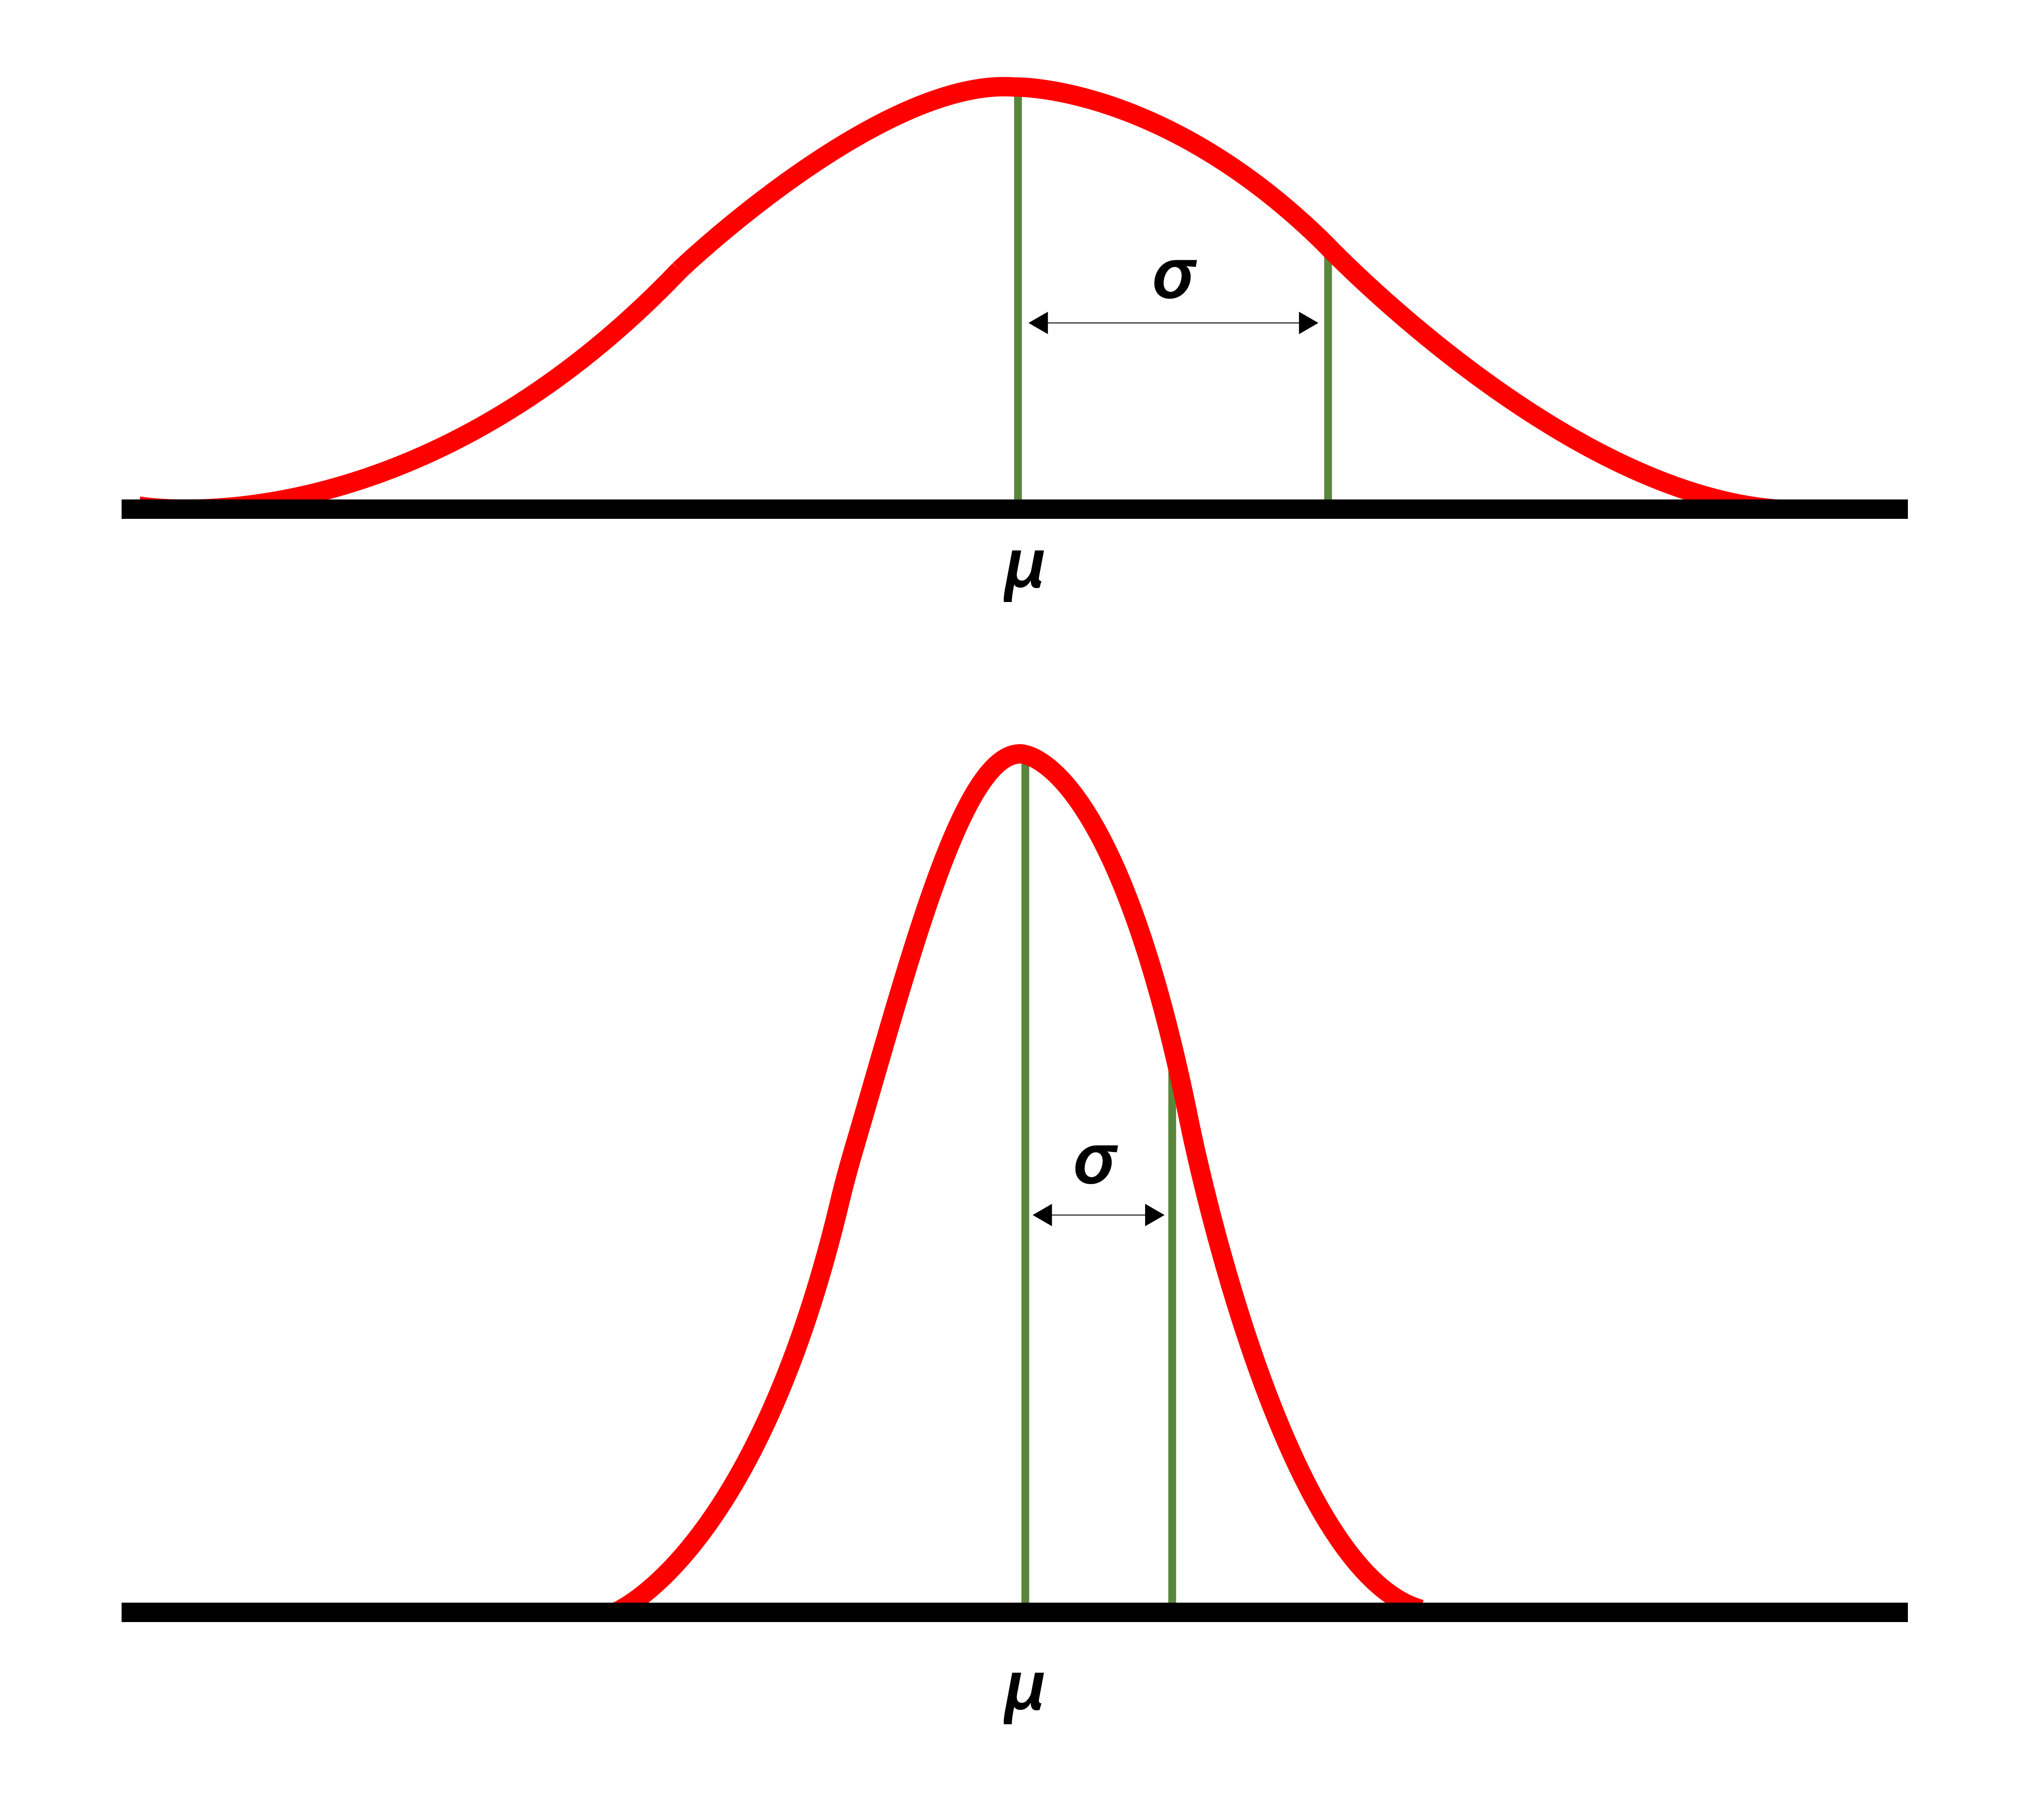

Think of it like testing the strength of concrete from two different suppliers. Both suppliers promise their concrete has an average compressive strength of 4000 psi (this is the mean).

**Supplier A (High Quality Control):** You test three samples from this supplier and get strengths of 3950, 4000, and 4050 psi. The results are all clustered very tightly around the 4000 psi average. This batch is consistent and predictable.

**Supplier B (Poor Quality Control):** You test three samples from this supplier and get strengths of 3000, 4000, and 5000 psi. The average is also 4000 psi, but the results are all over the place. One sample is dangerously weak, while another is much stronger than needed. This batch is inconsistent and unpredictable.

Supplier A's concrete would have a low standard deviation. Supplier B's concrete would have a high standard deviation. Even though their averages are identical, the standard deviation tells you that Supplier A's product is far more reliable and safe.

**Why Does the "Size" (Value) of the Standard Deviation Change?**
The value of the standard deviation is calculated directly from the distance of each data point to the mean.

When data is **consistent**, the standard deviation is small.

For Supplier A [3950, 4000, 4050], the distances from the 4000 psi mean are small (-50, 0, +50). The average of these distances will be small, resulting in a low standard deviation.

Visually, this data would look like a tall and skinny bell curve.

When data is **inconsistent**, the standard deviation is large.

For Supplier B [3000, 4000, 5000], the distances from the mean are huge (-1000, 0, +1000). The average of these distances will be very large, resulting in a high standard deviation.

Visually, this data would look like a short and wide bell curve, like the first image in your lesson.

**So what does this have to do with outliers?**

An outlier will dramatically increase the standard deviation.

An outlier, by definition, is a point that is very far from the mean—like a single concrete sample that tests at only 1500 psi.

Because its distance from the mean is so large, it pulls the "average distance" for the whole dataset way up, inflating the standard deviation.


This is exactly why we use it to find them!

Standard deviation gives us a standardized "ruler" to measure how far away a data point is.

If we know that about 95% of all data points in a normal distribution fall within 2 standard deviations of the mean we can be confident that a point that is 3 or 4 standard deviations away is highly unusual and likely an outlier that needs investigation.
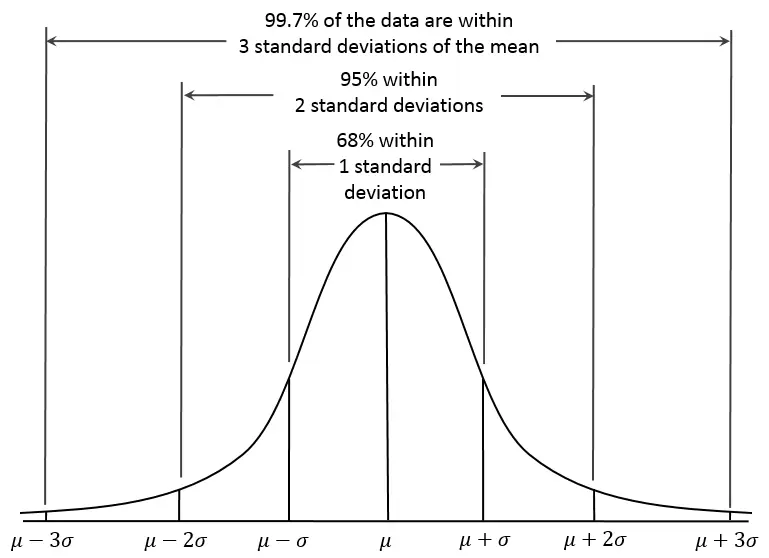

**Using Standard Deviation to Find an "Energy Hog"**

Imagine you are an energy manager for a portfolio of buildings.

Your goal is to identify buildings that are performing unusually, as they might be good candidates for an energy audit or retro-commissioning.

One of the simplest ways to flag an outlier is to see which buildings have an energy consumption that is significantly higher than the average for the portfolio.

In this exercise, we will use standard deviation as our yardstick. We'll define an "unusual" building as one whose energy usage is more than one standard deviation above the group's average.

Let's look at the data and the code to accomplish this.

In [ ]:
import pandas as pd

# Create a sample dataframe with information about building energy usage and age
data = {'Building': ['Building A', 'Building B', 'Building C', 'Building D', 'Building E', 'Building F'],
        'Year Built': [1990, 2000, 1980, 1960, 2010, 1975],
        'Energy Usage (kWh/m^2/year)': [150, 250, 200, 1000, 300, 400]}
df = pd.DataFrame(data)
df
# Notice that "Building D" has a much higher energy usage than the others.
# Let's see if our statistical approach can automatically flag it for us!!

In [ ]:
# Now, we'll write a program that uses the .mean() and .std() functions in pandas to identify and remove this outlier.

# --- Our Plan ---
# 1. Calculate the average energy usage for the whole portfolio.
# 2. Calculate the standard deviation to understand the "normal" spread of data.
# 3. Filter out any building whose energy usage is beyond one standard deviation from the mean.

# Calculate the mean and standard deviation of the energy usage column
mean_energy = df['Energy Usage (kWh/m^2/year)'].mean()
std_energy = df['Energy Usage (kWh/m^2/year)'].std()

print(f"Average Energy Usage: {mean_energy:.2f} kWh/m^2/year")
print(f"Standard Deviation: {std_energy:.2f} kWh/m^2/year")
print("-" * 30)



In [ ]:
# For each building, calculate how far its energy usage is from the mean.
# A large positive number means it's an energy hog; a negative number means it's efficient.
dif_from_mean = df['Energy Usage (kWh/m^2/year)'] - mean_energy

# Filter the dataframe. We want to KEEP only the buildings where the
# difference from the mean is LESS THAN OR EQUAL TO one standard deviation.
# This condition effectively removes anything that is too high.
filtered_df = df[dif_from_mean <= std_energy]
filtered_df

In [ ]:
# First, let's look at our original data
print("Original Building Portfolio:")
print(df)
print("-" * 30)

# Now, let's look at the portfolio after removing the outlier
print("Portfolio After Removing High-Energy Outlier:")
print(filtered_df)

# our program successfully identified and removed Building D!
#
# The average energy usage was about 383 kWh/m²/year, with a standard deviation of 314.
# This means a "normal" building in this dataset would likely fall within one standard deviation
# of the mean (i.e., have an energy usage less than 383 + 314 = 697).
#
# Building D, with an energy usage of 1000, was far outside this range and was therefore
# correctly flagged as an outlier that requires further investigation.

**Chosing the number of sigma**
That was a great first step, but a one-standard-deviation filter can sometimes be too strict, especially if there's natural variation in the data.

According to the statistical rule of thumb shown in the diagram, about 68% of data falls within one standard deviation, but **95% falls within two**.

**Your turn:** How could you do this for 2 standard deviation away from the mean?

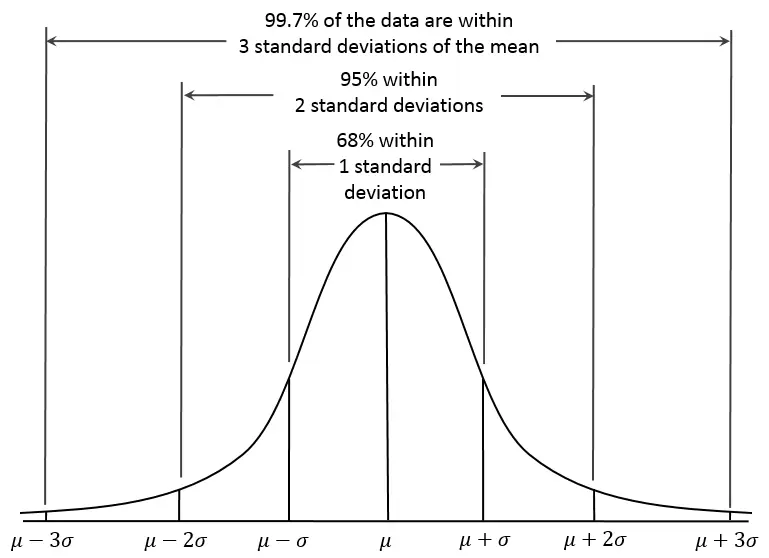

In [ ]:
# The only change is multiplying 'std' by 2 in our condition

# your turn!
# add your code here


### Using a Fixed Threshold: Applying an Engineering Standard

Sometimes, you don't need a complex statistical rule to find an outlier.

Instead, you might have:
*  a specific performance target
* a building code requirement,
* just a common-sense limit based on your professional experience.

This is where using a fixed threshold is a simple technique.

Instead of calculating the mean and standard deviation, you simply decide on a **cutoff value**.

Any data point that falls above (or below) this threshold is considered an outlier and is removed.


Let's use our same building portfolio.

Looking at the data, most buildings are below 400 kWh/m²/year.

The one at 1000 seems exceptionally high.

As an energy manager, you might set a performance target that any building using over 500 kWh/m²/year needs immediate investigation.

Our plan is even simpler this time:

* Define our performance threshold.

* Filter out any building that exceeds this threshold.

In [ ]:
# Define a performance threshold based on our domain knowledge.
# Any building using more than this amount is considered an outlier.
energy_threshold = 500

# Create a filtered DataFrame by keeping only the rows where
# the 'Energy Usage' is LESS THAN our threshold.
filtered_df_threshold = df[df['Energy Usage (kWh/m^2/year)'] < energy_threshold]

# First, let's look at our original data again
print("Original Building Portfolio:")
print(df)
print("-" * 30)

# Now, let's look at the portfolio after applying our performance standard
print(f"Portfolio After Removing Buildings Over {energy_threshold} kWh/m^2/year:")
print(filtered_df_threshold)

# The output shows that Building D was removed.

# This method was very direct.
# Unlike the standard deviation method, which is relative to the other data points, the threshold method is an absolute rule.
# It doesn't care what the mean or spread of the data is; it only cares whether a data point breaks the rule you've set.
# This makes it extremely useful when you have clear, predefined limits for what is considered acceptable performance.

So far, we've flagged buildings based on a single rule.

But in the real world, problems are often more complex.

A building might be an energy hog, but if it was just built last year, that points to a different problem (like a faulty HVAC system) than a building that is 50 years old and inefficient (which needs a deep retrofit).

To find the most critical buildings to investigate, we often need to filter based on **multiple conditions** at once.

Pandas makes this easy by letting us combine logical conditions. The two most important operators are:

* & (the "and" operator): Use this when you need a row to satisfy all of your conditions.

* | (the "or" operator): Use this when a row only needs to satisfy at least one of your conditions.

Syntax Note: When you combine conditions, each individual condition must be wrapped in its own set of parentheses ().



Example: Finding Old AND Inefficient Buildings

Let's say our goal is to find buildings that are prime candidates for a major renovation. Our criteria are:

* The building must be older than 30 years.

* AND it must have an energy usage over 450 kWh/m²/year.

This is a classic "and" problem because we only want the buildings that meet both criteria.

In [ ]:
# Use the same sample dataframe as before
data = {'Building': ['Building A', 'Building B', 'Building C', 'Building D', 'Building E', 'Building F'],
        'Year Built': [1990, 2000, 1980, 1960, 2010, 1975],
        'Energy Usage (kWh/m^2/year)': [150, 250, 200, 1000, 300, 400]}
df = pd.DataFrame(data)

# Let's add an 'Age' column to make our filtering easier
# For simplicity, we'll calculate age relative to the year 2025
df['Age'] = 2025 - df['Year Built']


In [ ]:
# Define our two thresholds
age_threshold = 30
energy_threshold = 450

# Create two boolean conditions. Each one will be a Series of True/False values.
condition1 = df['Age'] > age_threshold
condition2 = df['Energy Usage (kWh/m^2/year)'] > energy_threshold

# Now, combine them with the '&' (and) operator to find rows where BOTH are True
high_priority_buildings = df[condition1 & condition2]

print(f"High-Priority Buildings (Older than {age_threshold} AND Over {energy_threshold} kWh/m^2/year):")
print(high_priority_buildings)

#The output now shows only Building D.
#Building C was old (1980) but was very efficient (200), so it didn't meet the second condition.
# Building F was inefficient (400) but wasn't old enough (1975), so it didn't meet the first condition.
# Only Building D met both criteria: it was built in 1960 (before 1985) AND it used 1000 kWh/m²/year (over 350).

### Z score
We've seen that using one or two standard deviations can be a good way to find outliers.

The Z-score method takes this idea one step further by creating a standardized score for every single data point.

The Z-score tells you exactly how many standard deviations a data point is away from the mean.

* A Z-score of 1.5 means the data point is 1.5 standard deviations above the mean.

* A Z-score of -2.0 means the data point is 2.0 standard deviations below the mean.

* A Z-score of 0 means the data point is exactly the same as the mean.

This is incredibly useful in engineering because it removes the original units (like kWh/m² or psi) and gives us a universal scale of "unusualness."

To calculate the Z-score for any given data point (x), you use the following formula:

z= (x−μ) /σ

Where:

x is the individual data point.

μ (mu) is the mean of the dataset.

σ (sigma) is the standard deviation of the dataset.

While you can set any Z-score threshold you want, a widely accepted **rule of thumb** in statistics is to consider any data point with a Z-score **greater than 3 or less than -3 as an outlier.**

Why 3?

Because for a **normal** distribution of data (a bell curve), over 99.7% of all your data points will naturally fall within 3 standard deviations of the mean.

This means a point with a Z-score of 3.5 is so rare that it's highly likely to be an outlier caused by a measurement error or a truly exceptional event.

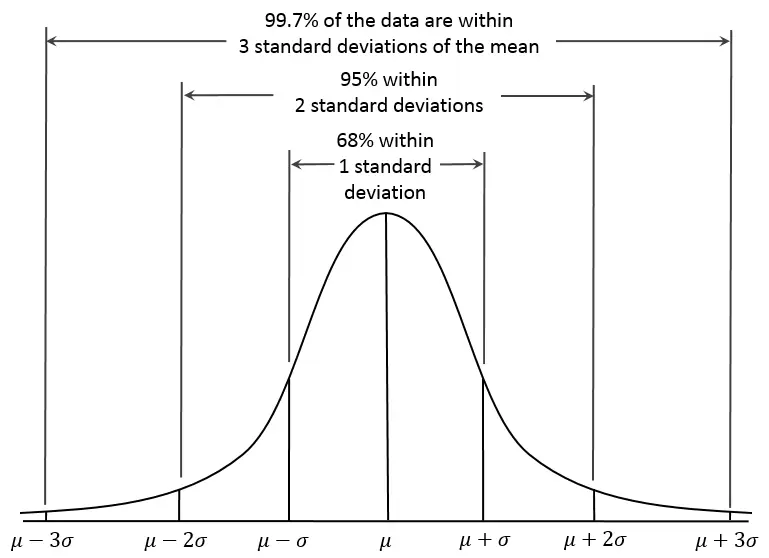

Let's apply it to our building portfolio.

While we could calculate the Z-score for each building manually using the formula, Python's scientific computing library, **scipy**, has a handy function that does it for us.



**Z-Score in Action: Predictive Maintenance for HVAC Fans**
Let's imagine you are monitoring the performance of a fleet of identical HVAC fan motors across a large university campus.

As part of a predictive maintenance program, you are collecting data on the electrical current (amperage) each motor draws while running.

Normally, these motors should draw around 10 amps.

A reading that is slightly higher or lower is normal, but a reading that is extremely high could indicate that a motor's bearings are failing and it's about to burn out.

Your goal is to use the Z-score method to automatically flag motors that need immediate inspection.

First let's generate a synthetic dataset.

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

# 1. Create 100 "normal" motor readings centered around 10 amps.
#    np.random.normal generates data that follows a bell curve.
normal_readings = np.random.normal(loc=10.0, scale=0.5, size=100)

# 2. Create a few "outlier" readings representing failing motors.
#    These values are intentionally far from the normal 10 amps.
outlier_readings = np.array([12.5, 14.0, 5.0]) # Two high, one unusually low (e.g., disconnected phase)

# 3. Combine them into a single dataset.
all_readings = np.concatenate([normal_readings, outlier_readings])

# Create the DataFrame
motors_df = pd.DataFrame({'Motor_ID': range(1, 104), 'Amperage': all_readings})
motors_df

In [ ]:
# Calculate the Z-score for each motor's amperage reading.
motors_df['Amperage_ZScore'] = stats.zscore(motors_df['Amperage'])

# Define our Z-score threshold using the standard statistical rule.
z_score_threshold = 3.0

# Filter the DataFrame to find the outliers.
# This time, we are looking for rows where the absolute Z-score is GREATER THAN our threshold.
outlier_motors = motors_df[abs(motors_df['Amperage_ZScore']) > z_score_threshold]
outlier_motors

## Visualizing outliers
There are several ways to visualize outliers in a dataset, depending on the nature and characteristics of the data. Here are some examples:

* Box plot: A box plot is a graphical representation of the distribution of the data based on the quartiles and the IQR. Outliers are typically shown as individual points outside the whiskers of the box plot. You can use the boxplot() function from the matplotlib library or the boxenplot() function from the seaborn library to create box plots of your data.

* Scatter plot: A scatter plot can be used to plot the values of two variables against each other, with each data point represented as a point on the plot. Outliers may be visible as data points that are significantly different from the rest of the data points. You can use the scatter() function from the matplotlib library or the scatterplot() function from the seaborn library to create scatter plots of your data.

* Histogram: A histogram is a graphical representation of the frequency distribution of a single variable. Outliers may be visible as bars that are significantly taller or shorter than the rest of the bars in the histogram. You can use the hist() function from the matplotlib library or the histplot() function from the seaborn library to create histograms of your data.

* Violin plot: A violin plot is a combination of a box plot and a kernel density plot, and shows the distribution of the data as well as the density of the data at different points. Outliers may be visible as individual points outside the violins of the plot. You can use the violinplot() function from the matplotlib library or the violinplot() function from the seaborn library to create violin plots of your data.

By visualizing the outliers in your data, you can gain a better understanding of their characteristics and identify any patterns or relationships that may be present. You can also use these visualizations to decide how to handle the outliers, such as by removing them from the dataset, transforming the data, or incorporating them into a separate analysis.

In [ ]:
# Let's create a box plot for our HVAC motor amperage data
# to see if the visual results match what our Z-score analysis told us.

# add your code here


But this shows 3 outliers though... why?
Z score only showed 2...?

Box plots use interquartile range!

Lesson to be learned here: Not all outlier detection methods will give you the same results! So how would we remove this pesky one?

Well you could either try the IQR method: https://www.educative.io/answers/how-to-identify-outliers-in-a-dataset-using-scipy-in-python

Or we could figure out where that specific entry is in our data.


---
## 📋 Today's In-Class Assignment

**The exercise above is your in-class assignment for today. Submit it to Canvas before you leave.**

To submit:
1. Make sure your code in the cell above runs without errors (press Shift+Enter to run it)
2. Take a screenshot of your code and its output
3. Go to the module on Canvas that this lesson was part of and find today's in-class assignment, due at midnight
4. Upload your screenshot

*If you have multiple screenshots, combine them into a single PDF before uploading.*

**You only need to show that you tried; this is graded on effort, not perfection.**

---

##**Key Takeaways from This Lesson**


**Key Takeaway=** An "outlier" is not a fixed definition.

As we saw, the Z-score method and the box plot (IQR) method gave us different results on the same dataset.

This is the most important lesson: different statistical methods use different rules to define what is "unusual."

**Key Takeaway=**  Outliers can skew your statistics.

The reason the Z-score method missed one of the outliers is that the other, more extreme outliers inflated the standard deviation.

This made the less extreme point seem statistically "closer" to the mean than it really was.

**Key Takeaway=** Always visualize your data.

A box plot is your best friend for outlier detection.

It gives you an instant visual confirmation of your data's distribution and helps you sanity-check the results of your numerical methods.


**Key Takeaway=**
Your expertise matters most!!

Ultimately, data cleaning is not just about running code; it's about making informed decisions.

Your job as an analyst is to use these tools, understand their strengths and weaknesses, and combine them with your domain knowledge to justify why a data point should or should not be removed.

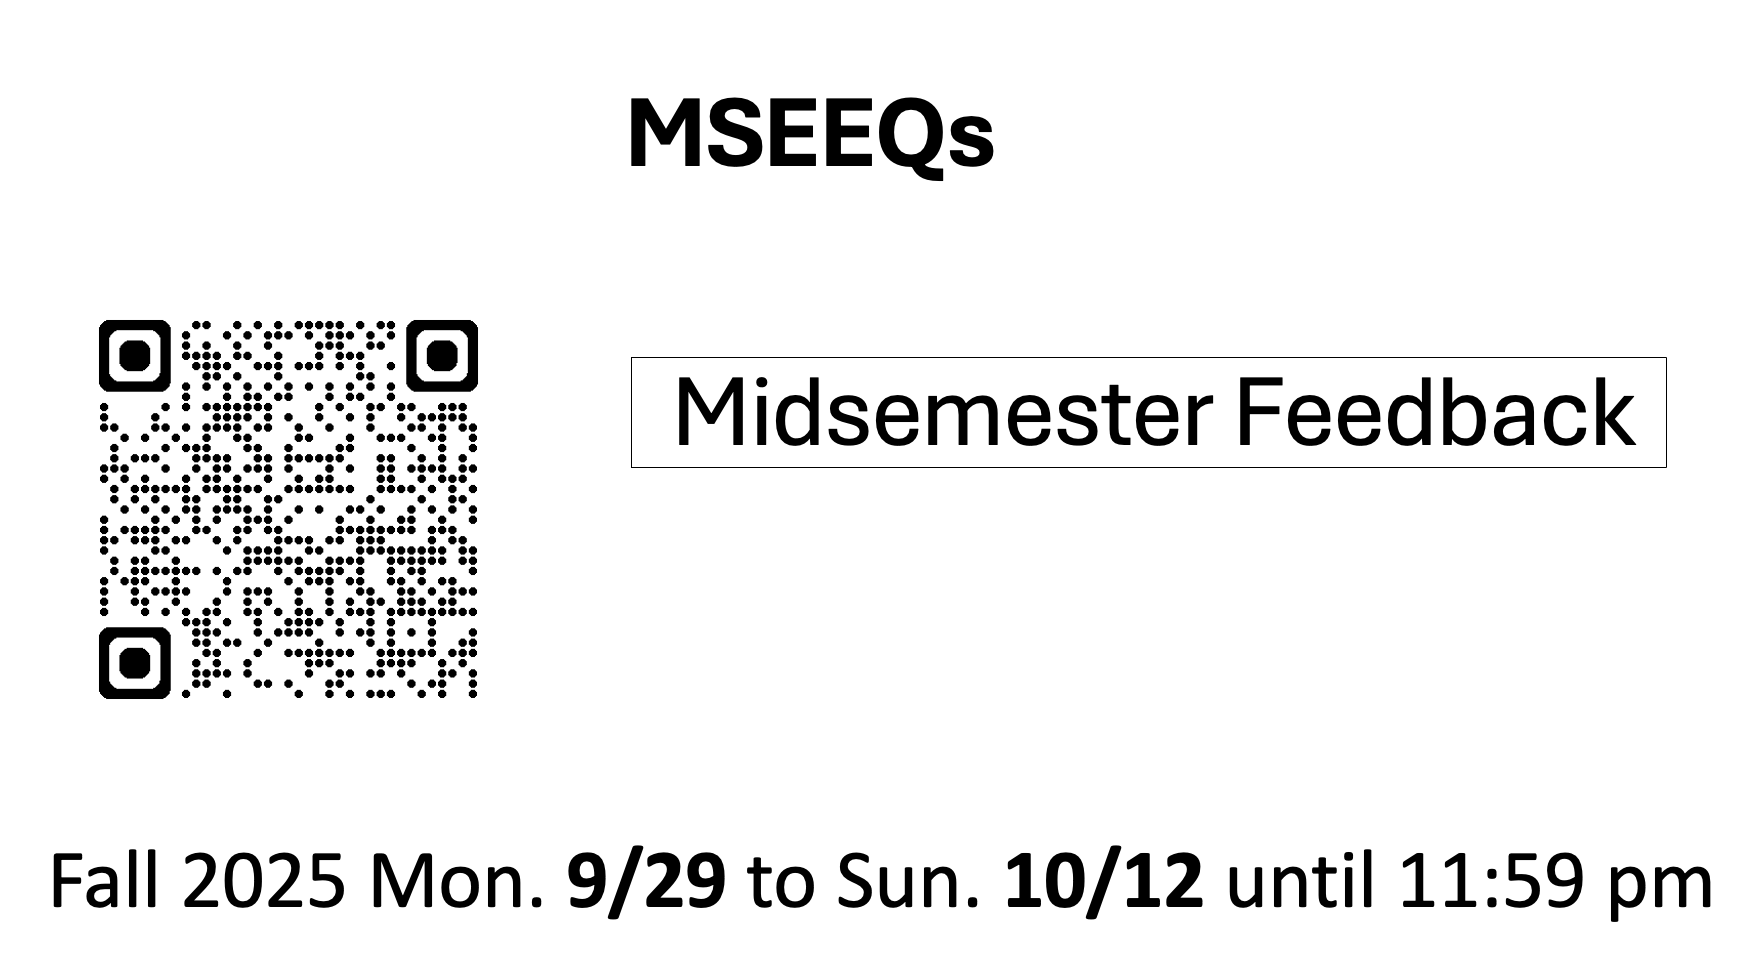